In [2]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.mixture import GaussianMixture
from tqdm import tqdm
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {torch.cuda.get_device_name(0)}')

Using device: NVIDIA GeForce RTX 5060 Ti


In [3]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

## 1. Data Loading

Load hyperspectral data and treat each pixel as an independent sample.
Uses PA2E model with P5 Conv1d-based encoder-decoder, then applies post-hoc GMM ranker on latent representations.

In [4]:
def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    import spectral
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)

def load_label(label_path):
    """Load label data."""
    return np.load(label_path)

def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data using white and dark references."""
    import spectral
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)
    
    # Average across spatial dimensions
    white_mean = white_ref.mean(axis=(0, 1))
    dark_mean = dark_ref.mean(axis=(0, 1))
    
    # Calibration
    calibrated = (data - dark_mean) / (white_mean - dark_mean + 1e-8)
    calibrated = np.clip(calibrated, 0, 1)
    
    return calibrated

In [5]:
class HSIPixelDataset(Dataset):
    """Dataset that treats each pixel as an independent sample."""
    
    def __init__(self, data, labels=None):
        self.data = data
        self.labels = labels
        
        H, W, B = data.shape
        self.pixels = data.reshape(-1, B)
        
        if labels is not None:
            self.pixel_labels = labels.reshape(-1)
        else:
            self.pixel_labels = None
        
        self.shape = (H, W)
    
    def __len__(self):
        return len(self.pixels)
    
    def __getitem__(self, idx):
        pixel = torch.from_numpy(self.pixels[idx]).float()
        
        if self.pixel_labels is not None:
            label = torch.tensor(self.pixel_labels[idx], dtype=torch.long)
            return pixel, label
        else:
            return pixel

In [6]:
# Load data for a specific food type
food_type = 'Almond'  # Change to 'Pistachio' or 'GarlicStems' as needed

base_path = f'../../AnomalyonFood/Dataset/{food_type}'

# Load training data (normal only)
train_data_path = f'{base_path}/Train/data.hdr'
train_white_path = f'{base_path}/Train/WHITEREF.hdr'
train_dark_path = f'{base_path}/Train/DARKREF.hdr'

print(f'Loading {food_type} training data...')
train_data = load_hsi_data(train_data_path)
train_data = calibrate_hsi(train_data, train_white_path, train_dark_path)

# Load test data (normal + anomalies)
test_data_path = f'{base_path}/Test/data.hdr'
test_white_path = f'{base_path}/Test/WHITEREF.hdr'
test_dark_path = f'{base_path}/Test/DARKREF.hdr'
test_label_path = f'{base_path}/Test/label.npy'

print(f'Loading {food_type} test data...')
test_data = load_hsi_data(test_data_path)
test_data = calibrate_hsi(test_data, test_white_path, test_dark_path)
test_labels = load_label(test_label_path)

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Number of bands: {train_data.shape[2]}')

Loading Almond training data...


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loading Almond test data...
Train data shape: (400, 512, 224)
Test data shape: (400, 512, 224)
Test labels shape: (400, 512)
Number of bands: 224


In [7]:
# Create datasets
train_dataset = HSIPixelDataset(train_data)
test_dataset = HSIPixelDataset(test_data, test_labels)

print(f'Training pixels: {len(train_dataset)}')
print(f'Test pixels: {len(test_dataset)}')
print(f'Spectrum dimension: {train_dataset.pixels.shape[1]}')

# Create dataloaders
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

Training pixels: 204800
Test pixels: 204800
Spectrum dimension: 224


## 2. P5 Overlapping PatchConv Model Architecture

### Components:
1. **Overlapping Patch Extractor** (redundant spectral coverage via stride)
2. **Partial Conv1d Encoders** (independent Conv1d per patch)
3. **Aggregate Encoder** (single FC layer)
4. **Decoder** (mirror of encoder, used only during training)

Based on P5 series from enc-dec_ablate-P.py

In [8]:
class OverlappingPatchExtractor(nn.Module):
    """Extract overlapping patches from spectrum with stride-based coverage."""
    
    def __init__(self, input_dim, patch_size, num_patches):
        super().__init__()
        self.input_dim = input_dim
        self.patch_size = patch_size
        self.num_patches = num_patches
        # Calculate stride for overlapping patches
        self.stride = max(1, (input_dim - patch_size) // (num_patches - 1))
    
    def forward(self, x):
        batch_size = x.size(0)
        patches = []
        
        for i in range(self.num_patches):
            start_idx = i * self.stride
            end_idx = min(start_idx + self.patch_size, self.input_dim)
            patch = x[:, start_idx:end_idx]
            
            # Pad if necessary
            if patch.size(1) < self.patch_size:
                padding = torch.zeros(batch_size, self.patch_size - patch.size(1), 
                                     device=x.device)
                patch = torch.cat([patch, padding], dim=1)
            
            patches.append(patch)
        
        return torch.stack(patches, dim=1)  # (batch, num_patches, patch_size)

In [9]:
class PartialConv1dEncoders(nn.Module):
    """Independent Conv1d encoders for each overlapping patch."""
    
    def __init__(self, num_patches, patch_size, latent_local_dim):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        self.latent_local_dim = latent_local_dim
        
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(1, 16, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.Conv1d(16, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1)
            )
            for _ in range(num_patches)
        ])
    
    def forward(self, patches):
        # patches: (batch, num_patches, patch_size)
        batch_size = patches.size(0)
        local_latents = []
        
        for i in range(self.num_patches):
            patch_i = patches[:, i, :].unsqueeze(1)  # (batch, 1, patch_size)
            latent_i = self.encoders[i](patch_i).squeeze(-1)  # (batch, latent_local_dim)
            local_latents.append(latent_i)
        
        local_latents = torch.stack(local_latents, dim=1)  # (batch, num_patches, latent_local_dim)
        return local_latents

In [10]:
class PartialConv1dDecoders(nn.Module):
    """Independent Conv1d decoders for each overlapping patch (mirror of encoders)."""
    
    def __init__(self, num_patches, patch_size, latent_local_dim):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        self.latent_local_dim = latent_local_dim
        
        self.decoders = nn.ModuleList([
            nn.Sequential(
                nn.ConvTranspose1d(32, 16, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.ConvTranspose1d(16, 1, kernel_size=5, padding=2)
            )
            for _ in range(num_patches)
        ])
    
    def forward(self, local_latents, patch_size):
        # local_latents: (batch, num_patches, latent_local_dim)
        batch_size = local_latents.size(0)
        reconstructed = []
        
        for i in range(self.num_patches):
            latent_i = local_latents[:, i, :]  # (batch, latent_local_dim)
            # Reshape latent to (batch, latent_local_dim, 1) then expand
            latent_i = latent_i.unsqueeze(-1).expand(-1, -1, patch_size)  # (batch, 32, patch_size)
            recon_i = self.decoders[i](latent_i).squeeze(1)  # (batch, patch_size)
            reconstructed.append(recon_i)
        
        return reconstructed

In [11]:
class PA2E_P5Conv(nn.Module):
    """PA2E with P5 Overlapping PatchConv encoder-decoder (Conv1d based)."""
    
    def __init__(self, input_dim, patch_size=56, num_patches=13, 
                 latent_local_dim=32, latent_global_dim=64):
        super().__init__()
        
        self.input_dim = input_dim
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.latent_local_dim = latent_local_dim
        self.latent_global_dim = latent_global_dim
        
        self.patch_extractor = OverlappingPatchExtractor(input_dim, patch_size, num_patches)
        print(f'Overlapping patch extractor initialized with stride: {self.patch_extractor.stride}')
        
        self.partial_encoders = PartialConv1dEncoders(num_patches, patch_size, latent_local_dim)
        
        concat_dim = num_patches * latent_local_dim
        self.aggregate_encoder = nn.Linear(concat_dim, latent_global_dim)
        
        self.aggregate_decoder = nn.Linear(latent_global_dim, concat_dim)
        
        self.partial_decoders = PartialConv1dDecoders(num_patches, patch_size, latent_local_dim)
        
        self.register_buffer('center', torch.zeros(latent_global_dim))
        self.center_initialized = False
    
    def encode(self, x):
        patches = self.patch_extractor(x)
        local_latents = self.partial_encoders(patches)
        
        batch_size = x.size(0)
        z_concat = local_latents.view(batch_size, -1)
        z = self.aggregate_encoder(z_concat)
        
        return z, local_latents
    
    def decode(self, z):
        z_concat = self.aggregate_decoder(z)
        
        batch_size = z.size(0)
        local_latents = z_concat.view(batch_size, self.num_patches, self.latent_local_dim)
        
        reconstructed_patches = self.partial_decoders(local_latents, self.patch_size)
        
        # Reconstruct with averaging for overlapping regions
        output = torch.zeros(batch_size, self.input_dim, device=z.device)
        counts = torch.zeros(self.input_dim, device=z.device)
        
        for i in range(self.num_patches):
            recon_patch = reconstructed_patches[i]
            
            start_idx = i * self.patch_extractor.stride
            end_idx = min(start_idx + self.patch_size, self.input_dim)
            length = end_idx - start_idx
            
            output[:, start_idx:end_idx] += recon_patch[:, :length]
            counts[start_idx:end_idx] += 1
        
        x_recon = output / (counts + 1e-8)
        return x_recon
    
    def forward(self, x):
        z, local_latents = self.encode(x)
        x_recon = self.decode(z)
        
        return z, x_recon

In [12]:
# Initialize model
input_dim = train_dataset.pixels.shape[1]

model = PA2E_P5Conv(
    input_dim=input_dim,
    patch_size=56,
    num_patches=13,
    latent_local_dim=32,
    latent_global_dim=64
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Overlapping patch extractor initialized with stride: 14
PA2E_P5Conv(
  (patch_extractor): OverlappingPatchExtractor()
  (partial_encoders): PartialConv1dEncoders(
    (encoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU()
        (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (3): ReLU()
        (4): AdaptiveAvgPool1d(output_size=1)
      )
    )
  )
  (aggregate_encoder): Linear(in_features=416, out_features=64, bias=True)
  (aggregate_decoder): Linear(in_features=64, out_features=416, bias=True)
  (partial_decoders): PartialConv1dDecoders(
    (decoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): ConvTranspose1d(32, 16, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): ReLU()
        (2): ConvTranspose1d(16, 1, kernel_size=(5,), stride=(1,), padding=(2,))
      )
    )
  )
)

Total parameters: 96,589


## 3. Training Procedure

### Two-Stage Training:
**Phase 1**: Pre-training with reconstruction loss (learn stable representations)
**Phase 2**: Main training with center loss + reconstruction loss (DSVDD-style)

In [13]:
def compute_reconstruction_loss(model, x):
    """Compute reconstruction loss for spectrum."""
    z, x_recon = model(x)
    loss = F.mse_loss(x_recon, x)
    
    return loss, z

def train_phase1(model, train_loader, num_epochs=50, lr=1e-3):
    """Phase 1: Pre-training with reconstruction loss."""
    print('\n=== Phase 1: Pre-training (Autoencoder) ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            loss, _ = compute_reconstruction_loss(model, x)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}')
    
    return losses


=== Phase 1: Pre-training (Autoencoder) ===


Epoch 1/30: 100%|██████████| 200/200 [00:05<00:00, 38.59it/s]


Epoch 1/30, Loss: 0.026272


Epoch 2/30: 100%|██████████| 200/200 [00:04<00:00, 42.95it/s]


Epoch 2/30, Loss: 0.002294


...

Epoch 28/30, Loss: 0.001200


Epoch 29/30: 100%|██████████| 200/200 [00:04<00:00, 44.03it/s]


Epoch 29/30, Loss: 0.001190


Epoch 30/30: 100%|██████████| 200/200 [00:04<00:00, 44.12it/s]


Epoch 30/30, Loss: 0.001169


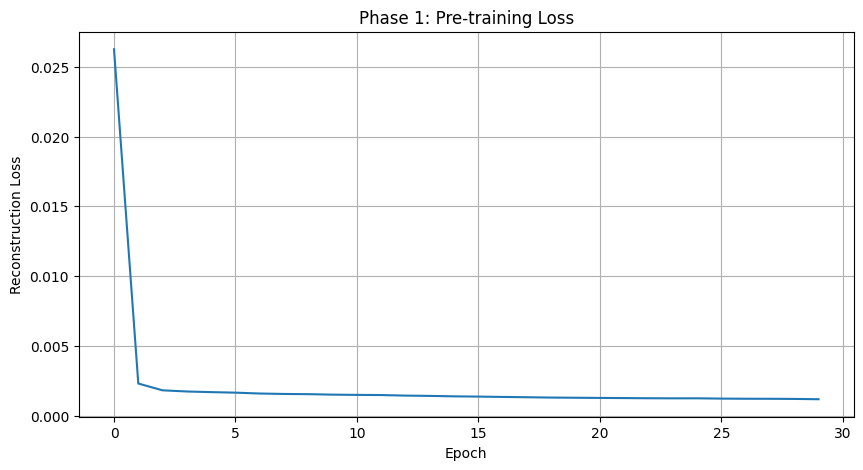

In [14]:
# Train Phase 1
phase1_losses = train_phase1(model, train_loader, num_epochs=30, lr=1e-3)

# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(phase1_losses)
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Phase 1: Pre-training Loss')
plt.grid(True)
plt.show()

## 4. Phase 2: Main Training (DSVDD)

In [15]:
def initialize_center(model, train_loader):
    """Compute center as mean of latent representations."""
    print('\nInitializing center...')
    
    model.eval()
    latents = []
    
    with torch.no_grad():
        for batch in tqdm(train_loader, desc='Computing center'):
            x = batch.to(device)
            z, _ = model.encode(x)
            latents.append(z)
    
    latents = torch.cat(latents, dim=0)
    center = latents.mean(dim=0)
    
    model.center = center
    model.center_initialized = True
    
    print(f'Center shape: {center.shape}')
    print(f'Center norm: {center.norm().item():.4f}')
    
    return center

def train_phase2(model, train_loader, num_epochs=50, lr=1e-4, alpha=0.1):
    """Phase 2: Main training with DSVDD-style loss."""
    print('\n=== Phase 2: Main Training (DSVDD-style) ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    center_losses = []
    recon_losses = []
    
    for epoch in range(num_epochs):
        initialize_center(model, train_loader)
        model.train()
        epoch_loss = 0
        epoch_center_loss = 0
        epoch_recon_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            recon_loss, z = compute_reconstruction_loss(model, x)
            center_loss = torch.mean(torch.sum((z - model.center) ** 2, dim=1))
            
            loss = center_loss + alpha * recon_loss
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_center_loss += center_loss.item()
            epoch_recon_loss += recon_loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        avg_center_loss = epoch_center_loss / len(train_loader)
        avg_recon_loss = epoch_recon_loss / len(train_loader)
        
        losses.append(avg_loss)
        center_losses.append(avg_center_loss)
        recon_losses.append(avg_recon_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Loss: {avg_loss:.6f}, '
              f'Center: {avg_center_loss:.6f}, '
              f'Recon: {avg_recon_loss:.6f}')
    
    return losses, center_losses, recon_losses


=== Phase 2: Main Training (DSVDD-style) ===

Initializing center...


Computing center: 100%|██████████| 200/200 [00:00<00:00, 373.97it/s]


Center shape: torch.Size([64])
Center norm: 2.6285


Epoch 1/30: 100%|██████████| 200/200 [00:04<00:00, 43.55it/s]


Epoch 1/30, Loss: 0.308161, Center: 0.307999, Recon: 0.001618

Initializing center...


...

Epoch 29/30, Loss: 0.000462, Center: 0.000254, Recon: 0.002078

Initializing center...


Computing center: 100%|██████████| 200/200 [00:00<00:00, 375.94it/s]


Center shape: torch.Size([64])
Center norm: 2.6247


Epoch 30/30: 100%|██████████| 200/200 [00:04<00:00, 44.08it/s]


Epoch 30/30, Loss: 0.000444, Center: 0.000244, Recon: 0.001998


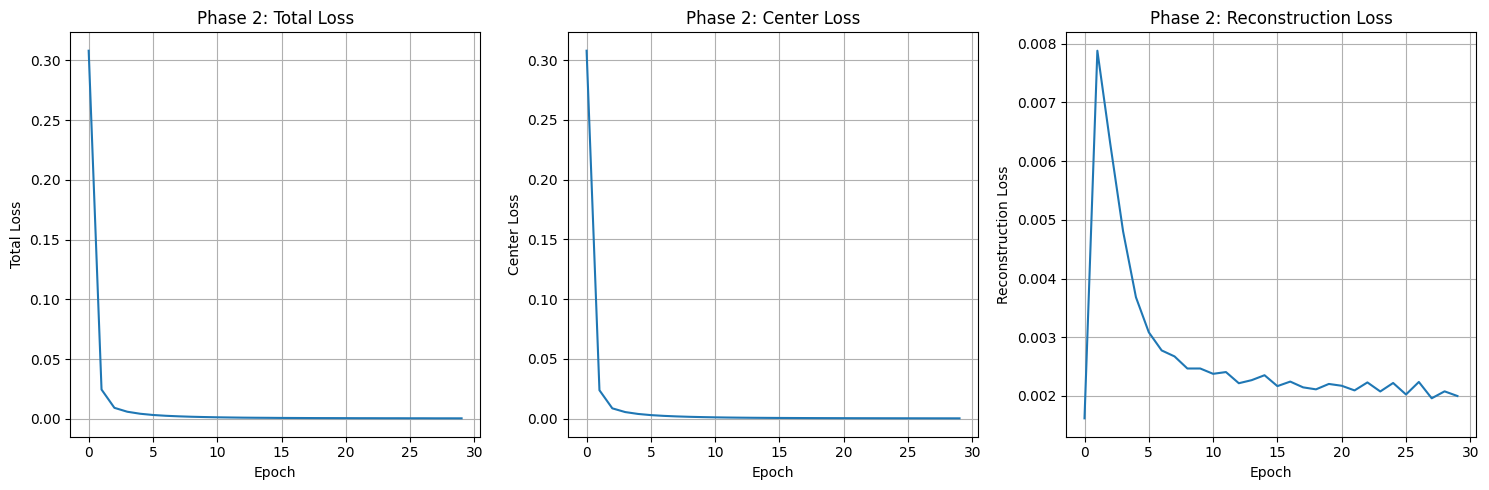

In [16]:
# Train Phase 2
phase2_losses, phase2_center_losses, phase2_recon_losses = train_phase2(
    model, train_loader, num_epochs=30, lr=1e-4, alpha=0.1
)

# Plot losses
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phase2_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Phase 2: Total Loss')
axes[0].grid(True)

axes[1].plot(phase2_center_losses)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Center Loss')
axes[1].set_title('Phase 2: Center Loss')
axes[1].grid(True)

axes[2].plot(phase2_recon_losses)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Reconstruction Loss')
axes[2].set_title('Phase 2: Reconstruction Loss')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 5. Extract Latent Representations

Extract latent vectors z from training and test data for GMM fitting.

In [17]:
def extract_latents(model, loader, return_labels=False):
    """Extract latent representations from data."""
    print('\nExtracting latent representations...')
    
    model.eval()
    all_latents = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting latents'):
            if return_labels:
                x, labels = batch
                all_labels.append(labels)
            else:
                x = batch
            
            x = x.to(device)
            z, _ = model.encode(x)
            all_latents.append(z.cpu().numpy())
    
    latents = np.concatenate(all_latents, axis=0)
    
    if return_labels:
        labels = torch.cat(all_labels).numpy()
        return latents, labels
    
    return latents

# Extract latents from training data
Z_train = extract_latents(model, train_loader)
print(f'Training latents shape: {Z_train.shape}')

# Extract latents from test data
Z_test, y_test = extract_latents(model, test_loader, return_labels=True)
print(f'Test latents shape: {Z_test.shape}')
print(f'Test labels shape: {y_test.shape}')

# Convert labels to binary (0=normal, 1=anomaly)
# Label 2 = normal, others = anomaly
y_test_binary = (y_test != 2).astype(int)
print(f'Normal pixels: {(y_test_binary == 0).sum()}')
print(f'Anomaly pixels: {(y_test_binary == 1).sum()}')


Extracting latent representations...


Extracting latents: 100%|██████████| 200/200 [00:00<00:00, 310.34it/s]


Training latents shape: (204800, 64)

Extracting latent representations...


Extracting latents: 100%|██████████| 200/200 [00:00<00:00, 206.34it/s]

Test latents shape: (204800, 64)
Test labels shape: (204800,)
Normal pixels: 201601
Anomaly pixels: 3199


## 6. Post-Hoc GMM Ranker

Fit Gaussian Mixture Model on training latents and use for anomaly scoring.
Based on the ranker ablation from ranker_ablate_paper.py

In [18]:
# GMM parameters (from ranker_ablate_paper.py)
K_GMM_VALUES = [2, 3, 5]

# Fit GMMs with different numbers of components
gmm_models = {}
gmm_scores = {}

for k in K_GMM_VALUES:
    print(f'\n--- Fitting GMM with K={k} ---')
    
    # Fit GMM on training latents
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED)
    gmm.fit(Z_train)
    
    # Score samples: negative likelihood = anomaly score
    # (higher score = more anomalous)
    scores = -gmm.score_samples(Z_test)
    
    gmm_models[k] = gmm
    gmm_scores[k] = scores
    
    # Compute metrics
    roc_auc = roc_auc_score(y_test_binary, scores)
    pr_auc = average_precision_score(y_test_binary, scores)
    
    print(f'GMM K={k}:')
    print(f'  ROC-AUC: {roc_auc:.4f}')
    print(f'  PR-AUC:  {pr_auc:.4f}')


--- Fitting GMM with K=2 ---
GMM K=2:
  ROC-AUC: 0.9103
  PR-AUC:  0.5780

--- Fitting GMM with K=3 ---
GMM K=3:
  ROC-AUC: 0.9187
  PR-AUC:  0.6146

--- Fitting GMM with K=5 ---
GMM K=5:
  ROC-AUC: 0.9406
  PR-AUC:  0.6657


In [19]:
# Summary comparison of GMM models
print('\n' + '='*50)
print('GMM MODEL COMPARISON')
print('='*50)

results_summary = {}

for k in K_GMM_VALUES:
    scores = gmm_scores[k]
    roc_auc = roc_auc_score(y_test_binary, scores)
    pr_auc = average_precision_score(y_test_binary, scores)
    
    results_summary[k] = {'ROC-AUC': roc_auc, 'PR-AUC': pr_auc}
    print(f'K={k}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}')

# Select best model
best_k = max(K_GMM_VALUES, key=lambda k: results_summary[k]['ROC-AUC'])
best_gmm = gmm_models[best_k]
best_scores = gmm_scores[best_k]
best_roc_auc = results_summary[best_k]['ROC-AUC']
best_pr_auc = results_summary[best_k]['PR-AUC']

print(f'\n✅ Best GMM: K={best_k} (ROC-AUC={best_roc_auc:.4f})')


GMM MODEL COMPARISON
K=2: ROC-AUC=0.9103, PR-AUC=0.5780
K=3: ROC-AUC=0.9187, PR-AUC=0.6146
K=5: ROC-AUC=0.9406, PR-AUC=0.6657

✅ Best GMM: K=5 (ROC-AUC=0.9406)


## 7. Evaluation and Visualization

/tmp/ipykernel_4869/3875003366.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


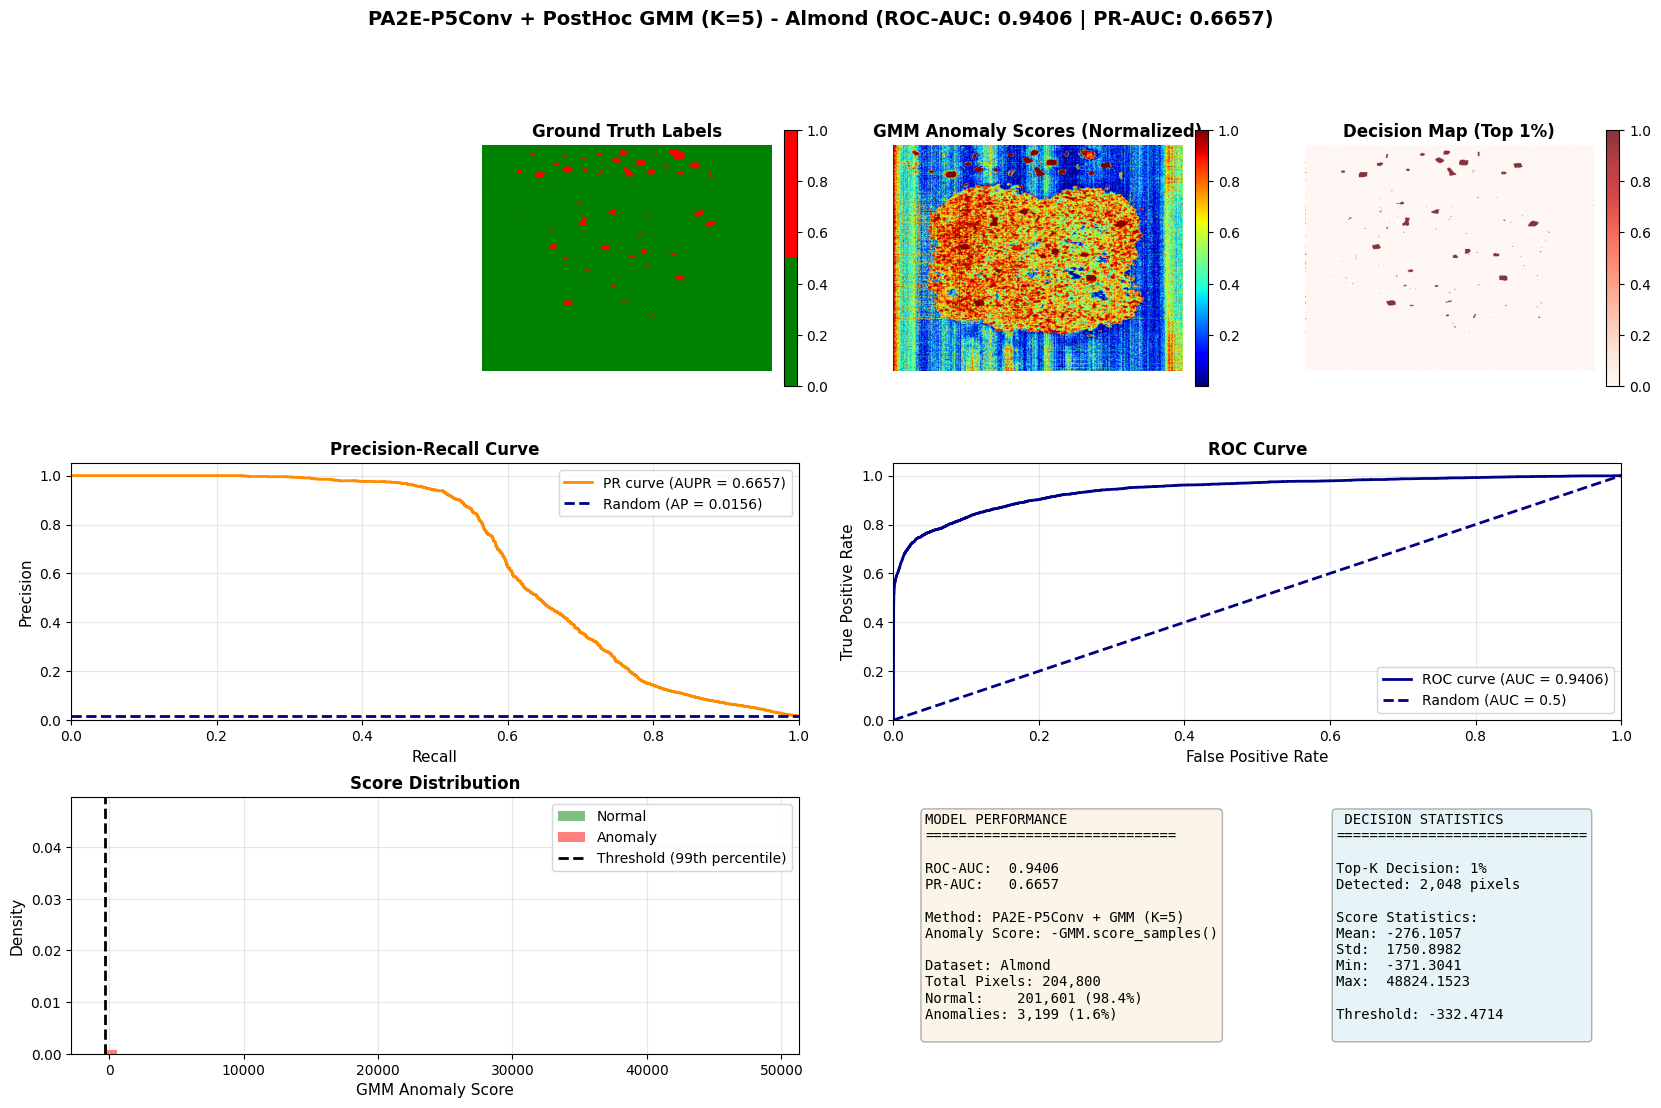


✅ Visualization complete!
   Top-K decision (1%): 2,048 pixels detected as anomalous


In [20]:
# Use best GMM for visualization
scores = best_scores
labels = y_test_binary
roc_auc = best_roc_auc
pr_auc = best_pr_auc

# Compute normalized rank scores for visualization
from scipy.stats import rankdata
rank_scores = rankdata(scores, method="average") / len(scores)
normalized_scores = rank_scores

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1  # Top 1% as anomalies
k_pixels = int(np.ceil(len(scores) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-scores)[:k_pixels]
pixel_decision = np.zeros(len(scores), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map = scores.reshape(H, W)
normalized_score_map = normalized_scores.reshape(H, W)
label_map = labels.reshape(H, W)
decision_map = pixel_decision.reshape(H, W)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im1 = ax1.imshow(label_map, cmap=cmap_binary)
ax1.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = fig.add_subplot(gs[0, 2])
im2 = ax2.imshow(normalized_score_map, cmap='jet')
ax2.set_title('GMM Anomaly Scores (Normalized)', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 3])
im3 = ax3.imshow(decision_map, cmap='Reds', alpha=0.8)
ax3.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax4 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(labels, scores)
ax4.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = labels.sum() / len(labels)
ax4.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('Recall', fontsize=11)
ax4.set_ylabel('Precision', fontsize=11)
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(labels, scores)
ax5.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax5.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('False Positive Rate', fontsize=11)
ax5.set_ylabel('True Positive Rate', fontsize=11)
ax5.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='lower right')
ax5.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax6 = fig.add_subplot(gs[2, 0:2])
ax6.hist(scores[labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax6.hist(scores[labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax6.axvline(np.percentile(scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax6.set_xlabel('GMM Anomaly Score', fontsize=11)
ax6.set_ylabel('Density', fontsize=11)
ax6.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

ax7 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""MODEL PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: PA2E-P5Conv + GMM (K={best_k})
Anomaly Score: -GMM.score_samples()

Dataset: {food_type}
Total Pixels: {len(scores):,}
Normal:    {(labels == 0).sum():,} ({100*(labels==0).sum()/len(labels):.1f}%)
Anomalies: {(labels == 1).sum():,} ({100*(labels==1).sum()/len(labels):.1f}%)
"""
ax7.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax7.axis('off')

ax8 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision.sum():,} pixels

Score Statistics:
Mean: {scores.mean():.4f}
Std:  {scores.std():.4f}
Min:  {scores.min():.4f}
Max:  {scores.max():.4f}

Threshold: {np.percentile(scores, 100 - TOP_K_PERCENT):.4f}
"""
ax8.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax8.axis('off')

plt.suptitle(f'PA2E-P5Conv + PostHoc GMM (K={best_k}) - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete!")
print(f"   Top-K decision ({TOP_K_PERCENT}%): {pixel_decision.sum():,} pixels detected as anomalous")

In [21]:
# Save model and results
import json

save_dir = '.'
model_path = f'{save_dir}/pa2e_p5conv_posthoc_gmm_{food_type.lower()}.pth'
gmm_path = f'{save_dir}/gmm_k{best_k}_{food_type.lower()}_p5conv.pkl'
results_path = f'{save_dir}/pa2e_p5conv_posthoc_gmm_results_{food_type.lower()}.json'

# Save PA2E-P5Conv model
torch.save({
    'model_state_dict': model.state_dict(),
    'center': model.center,
    'config': {
        'input_dim': input_dim,
        'patch_size': 56,
        'num_patches': 13,
        'latent_local_dim': 32,
        'latent_global_dim': 64
    }
}, model_path)

# Save GMM model
import pickle
with open(gmm_path, 'wb') as f:
    pickle.dump(best_gmm, f)

# Save results
results_data = {
    'dataset': food_type,
    'method': f'PA2E-P5Conv + PostHoc GMM (K={best_k})',
    'metrics': {
        'roc_auc': float(best_roc_auc),
        'pr_auc': float(best_pr_auc)
    },
    'gmm_k': int(best_k),
    'all_k_results': {int(k): v for k, v in results_summary.items()}
}

with open(results_path, 'w') as f:
    json.dump(results_data, f, indent=2)

print(f'\n✅ Models and results saved:')
print(f'   PA2E-P5Conv model: {model_path}')
print(f'   GMM model: {gmm_path}')
print(f'   Results: {results_path}')


✅ Models and results saved:
   PA2E-P5Conv model: ./pa2e_p5conv_posthoc_gmm_almond.pth
   GMM model: ./gmm_k5_almond_p5conv.pkl
   Results: ./pa2e_p5conv_posthoc_gmm_results_almond.json


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Generating UMAP visualization of test features...


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fit complete. Shape: (204800, 2)


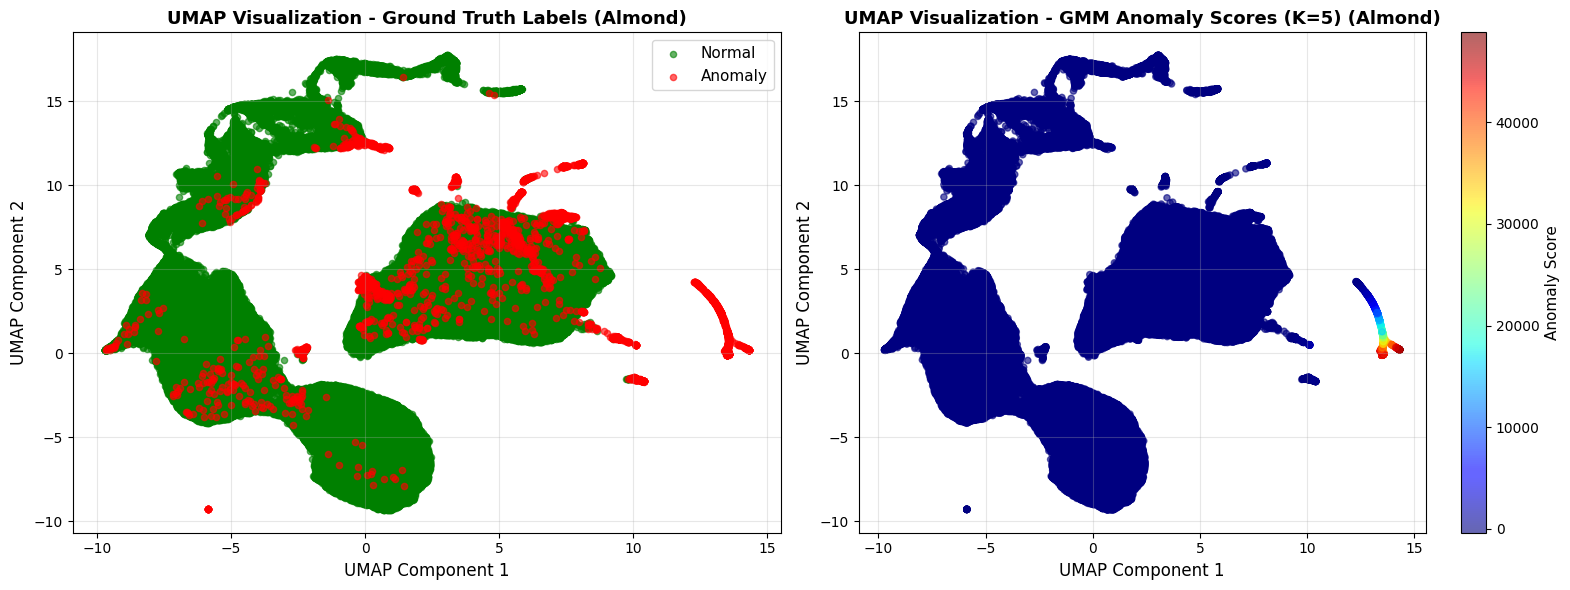


✅ UMAP visualization complete!
   Normal points (green): 201,601
   Anomaly points (red): 3,199


In [22]:
# UMAP Visualization of Test Features with Labels
from umap import UMAP

print('\nGenerating UMAP visualization of test features...')

# Fit UMAP on test latents
umap_reducer = UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
Z_test_umap = umap_reducer.fit_transform(Z_test)

print(f'UMAP fit complete. Shape: {Z_test_umap.shape}')

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: UMAP colored by ground truth label
ax1 = axes[0]
scatter1 = ax1.scatter(Z_test_umap[y_test_binary == 0, 0], 
                       Z_test_umap[y_test_binary == 0, 1],
                       c='green', label='Normal', alpha=0.6, s=20)
scatter2 = ax1.scatter(Z_test_umap[y_test_binary == 1, 0], 
                       Z_test_umap[y_test_binary == 1, 1],
                       c='red', label='Anomaly', alpha=0.6, s=20)
ax1.set_xlabel('UMAP Component 1', fontsize=12)
ax1.set_ylabel('UMAP Component 2', fontsize=12)
ax1.set_title(f'UMAP Visualization - Ground Truth Labels ({food_type})', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: UMAP colored by GMM anomaly score
ax2 = axes[1]
scatter3 = ax2.scatter(Z_test_umap[:, 0], Z_test_umap[:, 1],
                       c=best_scores, cmap='jet', alpha=0.6, s=20)
ax2.set_xlabel('UMAP Component 1', fontsize=12)
ax2.set_ylabel('UMAP Component 2', fontsize=12)
ax2.set_title(f'UMAP Visualization - GMM Anomaly Scores (K={best_k}) ({food_type})', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter3, ax=ax2)
cbar.set_label('Anomaly Score', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n✅ UMAP visualization complete!')
print(f'   Normal points (green): {(y_test_binary == 0).sum():,}')
print(f'   Anomaly points (red): {(y_test_binary == 1).sum():,}')

GMM PARAMETERS (K=5)

📊 Component Means (μ_k):
   Shape: (5, 64)
   μ_0: [-0.1000826   0.43482816  0.1573651   0.8336576  -0.27841917]... (first 5 dims)
   μ_1: [-0.09885093  0.43465686  0.156879    0.83313316 -0.27848753]... (first 5 dims)
   μ_2: [-0.09984519  0.43455565  0.15666936  0.8324758  -0.278232  ]... (first 5 dims)
   μ_3: [-0.09964909  0.43515196  0.1570026   0.83405966 -0.27860093]... (first 5 dims)
   μ_4: [-0.09863956  0.43493232  0.15732434  0.833098   -0.27854216]... (first 5 dims)

📊 Component Weights (π_k):
   Shape: (5,)
   π_0: 0.166973
   π_1: 0.192886
   π_2: 0.473066
   π_3: 0.043494
   π_4: 0.123582

📊 Component Covariances (Σ_k):
   Shape: (5, 64, 64)
   Σ_0 shape: (64, 64)
   Trace: 0.000278
   Det: 0.000000e+00
   Σ_1 shape: (64, 64)
   Trace: 0.000316
   Det: 0.000000e+00
   Σ_2 shape: (64, 64)
   Trace: 0.000169
   Det: 0.000000e+00
   Σ_3 shape: (64, 64)
   Trace: 0.000462
   Det: 0.000000e+00
   Σ_4 shape: (64, 64)
   Trace: 0.000240
   Det: 0.000000e+0

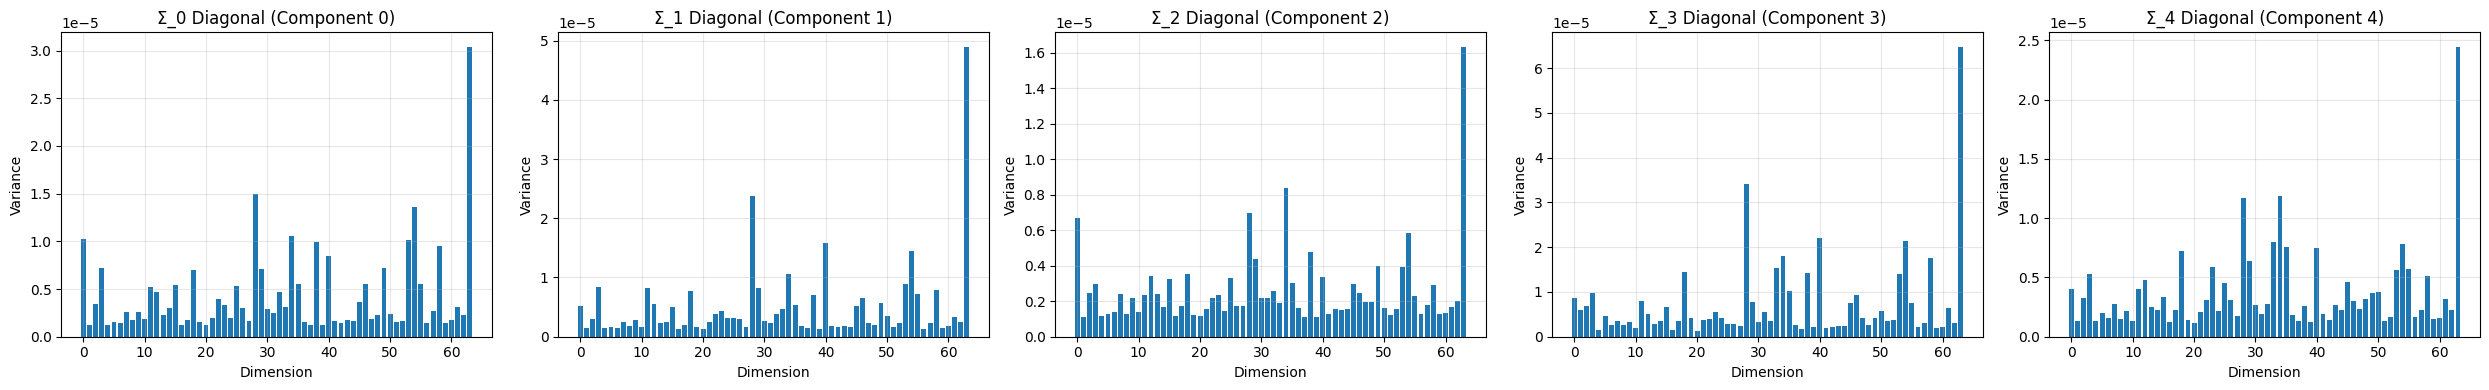


✅ GMM parameter extraction complete!
   Total components: 5
   Latent dimension: 64
   Parameters saved to: ./gmm_parameters_p5conv_almond.json


In [23]:
# Extract GMM Parameters: μ_k, Σ_k, π_k
import json

print('='*70)
print(f'GMM PARAMETERS (K={best_k})')
print('='*70)

# Extract parameters
mu_k = best_gmm.means_           # Component means (μ_k)
sigma_k = best_gmm.covariances_  # Component covariances (Σ_k)
pi_k = best_gmm.weights_         # Component weights (π_k)

print(f'\n📊 Component Means (μ_k):')
print(f'   Shape: {mu_k.shape}')
for k in range(best_k):
    print(f'   μ_{k}: {mu_k[k][:5]}... (first 5 dims)')

print(f'\n📊 Component Weights (π_k):')
print(f'   Shape: {pi_k.shape}')
for k in range(best_k):
    print(f'   π_{k}: {pi_k[k]:.6f}')

print(f'\n📊 Component Covariances (Σ_k):')
print(f'   Shape: {sigma_k.shape}')
for k in range(best_k):
    print(f'   Σ_{k} shape: {sigma_k[k].shape}')
    print(f'   Trace: {np.trace(sigma_k[k]):.6f}')
    print(f'   Det: {np.linalg.det(sigma_k[k]):.6e}')

# Visualize covariance structure (diagonal elements)
print(f'\n📊 Covariance Diagonal Elements:')
fig, axes = plt.subplots(1, best_k, figsize=(5*best_k, 4))
if best_k == 1:
    axes = [axes]

for k in range(best_k):
    diag_elements = np.diag(sigma_k[k])
    axes[k].bar(range(len(diag_elements)), diag_elements)
    axes[k].set_xlabel('Dimension')
    axes[k].set_ylabel('Variance')
    axes[k].set_title(f'Σ_{k} Diagonal (Component {k})')
    axes[k].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save GMM parameters to JSON
gmm_params_data = {
    'dataset': food_type,
    'gmm_k': int(best_k),
    'latent_dimension': int(mu_k.shape[1]),
    'means_mu_k': {
        f'mu_{k}': mu_k[k].tolist() for k in range(best_k)
    },
    'weights_pi_k': {
        f'pi_{k}': float(pi_k[k]) for k in range(best_k)
    },
    'covariances_sigma_k': {
        f'sigma_{k}': {
            'matrix': sigma_k[k].tolist(),
            'trace': float(np.trace(sigma_k[k])),
            'determinant': float(np.linalg.det(sigma_k[k])),
            'diagonal': np.diag(sigma_k[k]).tolist()
        }
        for k in range(best_k)
    }
}

gmm_params_path = f'./gmm_parameters_p5conv_{food_type.lower()}.json'
with open(gmm_params_path, 'w') as f:
    json.dump(gmm_params_data, f, indent=2)

print(f'\n✅ GMM parameter extraction complete!')
print(f'   Total components: {best_k}')
print(f'   Latent dimension: {mu_k.shape[1]}')
print(f'   Parameters saved to: {gmm_params_path}')